In [1]:
### IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1. DATA ACQUISITION
# Fetching the California Housing dataset as a Pandas DataFrame
housing = fetch_california_housing(as_frame=True)
df = housing.frame


In [3]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# Inspecting structure, missing values, and statistical distribution
df.head()
df.isnull().sum() # Checking for nulls to ensure data quality
df.describe()    # Reviewing mean, std, and quartiles
df.info()        # Confirming data types (all numeric)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# 3. FEATURE SELECTION & TARGET DEFINITION
# MedHouseVal is the target variable (expressed in $100,000s)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Checking correlations to see which features relate most to price
X.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


In [5]:
# 4. DATA SPLITTING
# Using an 80/20 split with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# 5. PREPROCESSING PIPELINE
# Creating a list of numerical columns for scaling
num_cols = X.columns.tolist()

# Applying StandardScaler to ensure features like 'Population' and 'AveRooms' 
# are on the same scale, which helps many regressor algorithms converge faster
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), num_cols)], 
    remainder='passthrough'
)

In [7]:
# 6. INITIAL MODEL TRAINING (Baseline)
# Starting with a Random Forest with 200 trees
model = RandomForestRegressor(random_state=42, n_estimators=200)

# Bundling preprocessing and modeling into a single Pipeline object
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])

# Training the baseline model
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [8]:
# 7. EVALUATION METRICS
# Calculating error (RMSE) and variance explained (R2)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Final RMSE ($): {rmse:.4f} (Approx. ${rmse * 100000:.0f})')
print(f'R2 Score: {r2:.4f}')

Mean Squared Error (MSE): 0.2538
Final RMSE ($): 0.5038 (Approx. $50378)
R2 Score: 0.8063


C:\Users\gidad\AppData\Local\Temp\ipykernel_15836\3208725279.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Features', data=importance_df, palette='viridis')


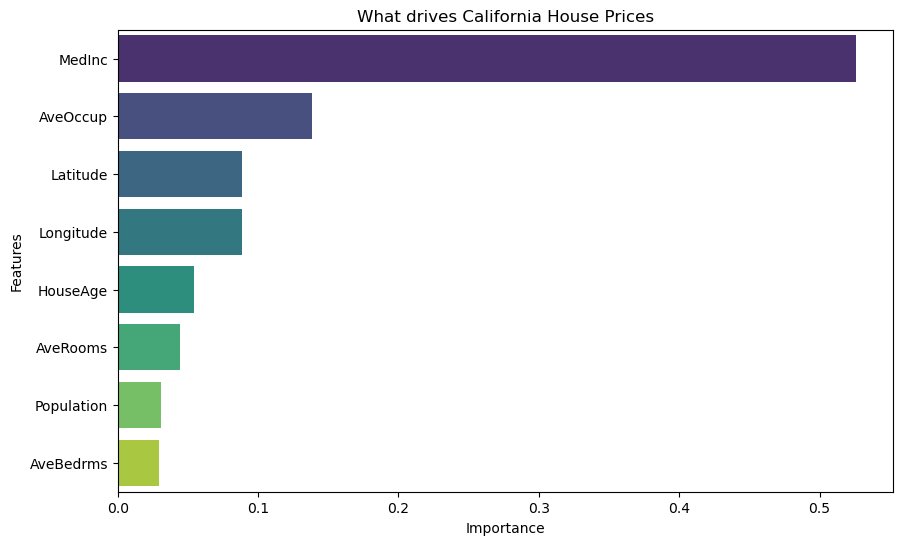

In [9]:
# 8. FEATURE IMPORTANCE VISUALIZATION
# Extracting which variables the forest found most useful for prediction
importances = pipeline.named_steps['regressor'].feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Features': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Features', data=importance_df, palette='viridis')
plt.title('What drives California House Prices')
plt.show()

In [10]:
# 9. OVERFITTING ANALYSIS
# Comparing Train vs Test R2 to check for "Generalization Gap"
y_pred_train = pipeline.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
gap = r2_train - r2
print(f"Training R2: {r2_train:.4f} | Test R2: {r2:.4f} | Gap: {gap:.4f}")

Training R2: 0.9742 | Test R2: 0.8063 | Gap: 0.1679


In [11]:
# 10. HYPERPARAMETER TUNING (Grid Search)
# Testing different tree depths and split requirements to find the best balance
param_grid_strict = {
    'regressor__max_depth': [4, 6, 8],
    'regressor__min_samples_split': [15, 20],
    'regressor__min_samples_leaf': [5, 10]
}

# 3-fold Cross Validation to find the most robust parameters
grid_search_strict = GridSearchCV(
    param_grid=param_grid_strict, 
    cv=3, 
    estimator=pipeline, 
    scoring='r2', 
    verbose=1, 
    n_jobs=1
)

grid_search_strict.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['MedInc',
                                                                          'HouseAge',
                                                                          'AveRooms',
                                                                          'AveBedrms',
                                                                          'Population',
                                                                          'AveOccup',
                                                                          'Latitude',
                                                                          'Longitude'])])),
                                       ('regressor',
                                        RandomForestRegressor(n_estimators=200,
                                                              random_state=42))]),
             n_jobs=1,
             param_grid={'regressor__max_depth': [4, 6, 8],
                         'regressor__min_samples_leaf': [5, 10],
                         'regressor__min_samples_split': [15, 20]},
             scoring='r2', verbose=1)

In [12]:
# 11. FINAL MODEL SELECTION
# Using the "best_estimator_" from GridSearch for final predictions
best_pipeline = grid_search_strict.best_estimator_
y_pred_tuned_final = best_pipeline.predict(X_test)
y_pred_train_strict = best_pipeline.predict(X_train)

# Final evaluation of the regularized model
r2_final_test = r2_score(y_test, y_pred_tuned_final)
r2_final_train = r2_score(y_train, y_pred_train_strict)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_tuned_final))

print(f"\n--- FINAL REGULARIZED MODEL RESULTS ---")
print(f'R2 Score (Test): {r2_final_test:.4f}')
print(f'R2 Score (Train): {r2_final_train:.4f}')
print(f'New Overfitting Gap: {(r2_final_train - r2_final_test):.4f}')
print(f'Final RMSE ($): {rmse_final:.4f} (Approx. ${rmse_final * 100000:.0f})')


--- FINAL REGULARIZED MODEL RESULTS ---
R2 Score (Test): 0.7397
R2 Score (Train): 0.7989
New Overfitting Gap: 0.0592
Final RMSE ($): 0.5841 (Approx. $58407)
